In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, mean_squared_error, roc_auc_score

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
prior = pd.read_csv('data/instacart/order_products__prior.csv')
products = pd.read_csv('data/instacart/products.csv')
orders = pd.read_csv('data/instacart/orders.csv')
aisles = pd.read_csv('data/instacart/aisles.csv')

In [10]:
prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [11]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [13]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [14]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [20]:
_ = pd.merge(prior, products, on='product_id')
_ = pd.merge(_, orders, on='order_id')
mt = pd.merge(_, aisles, on='aisle_id')
print(mt.info())
mt.head()

<class 'pandas.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 14 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       int64  
 3   reordered               int64  
 4   product_name            str    
 5   aisle_id                int64  
 6   department_id           int64  
 7   user_id                 int64  
 8   eval_set                str    
 9   order_number            int64  
 10  order_dow               int64  
 11  order_hour_of_day       int64  
 12  days_since_prior_order  float64
 13  aisle                   str    
dtypes: float64(1), int64(10), str(3)
memory usage: 3.4 GB
None


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle
0,2,33120,1,1,Organic Egg Whites,86,16,202279,prior,3,5,9,8.0,eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,202279,prior,3,5,9,8.0,fresh vegetables
2,2,9327,3,0,Garlic Powder,104,13,202279,prior,3,5,9,8.0,spices seasonings
3,2,45918,4,1,Coconut Butter,19,13,202279,prior,3,5,9,8.0,oils vinegars
4,2,30035,5,0,Natural Sweetener,17,13,202279,prior,3,5,9,8.0,baking ingredients


In [21]:
# 交叉表是一种用于显示两个或多个分类变量之间关系的表格。
# 它可以帮助我们理解不同类别之间的关系和分布情况。
cross = pd.crosstab(mt['user_id'], mt['aisle'])
cross.head()

aisle,air fresheners candles,asian foods,baby accessories,baby bath body care,baby food formula,bakery desserts,baking ingredients,baking supplies decor,beauty,beers coolers,...,spreads,tea,tofu meat alternatives,tortillas flat bread,trail mix snack mix,trash bags liners,vitamins supplements,water seltzer sparkling water,white wines,yogurt
user_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
2,0,3,0,0,0,0,2,0,0,0,...,3,1,1,0,0,0,0,2,0,42
3,0,0,0,0,0,0,0,0,0,0,...,4,1,0,0,0,0,0,2,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
5,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3


In [ ]:
# PCA（Principal Component Analysis，主成分分析）是一种常用的降维技术，用于将高维数据转换为低维数据，同时尽可能保留原始数据的变异性。
pca = PCA(n_components=0.9)
data = pca.fit_transform(cross)
data

array([[-2.42156587e+01, -2.42942720e+00, -2.46636975e+00, ...,
         6.86800336e-01,  1.69439402e+00, -2.34323022e+00],
       [ 6.46320806e+00, -3.67511165e+01,  8.38255336e+00, ...,
         4.12121252e+00,  2.44689740e+00, -4.28348478e+00],
       [-7.99030162e+00, -2.40438257e+00, -1.10300641e+01, ...,
         1.77534453e+00, -4.44194030e-01,  7.86665571e-01],
       ...,
       [ 8.61143331e+00, -7.70129866e+00,  7.95240226e+00, ...,
        -2.74252456e+00,  1.07112531e+00, -6.31925661e-02],
       [ 8.40862199e+01, -2.04187340e+01,  8.05410372e+00, ...,
         7.27554259e-01,  3.51339470e+00, -1.79079914e+01],
       [-1.39534562e+01, -6.64621821e+00, -5.23030367e+00, ...,
         8.25329076e-01,  1.38230701e+00, -2.41942061e+00]],
      shape=(206209, 27))

In [29]:
# KMeans算法是一种无监督学习算法，用于将数据分成K个簇。
# 它通过迭代的方式来优化簇的中心点，使得每个数据点都被分配到最近的中心点所在的簇中。
# KMeans算法的步骤如下：
# 1. 初始化：随机选择K个数据点作为初始的簇中心
# 2. 分配：将每个数据点分配到最近的簇中心所在的簇中
# 3. 更新：重新计算每个簇的中心点
# 4. 重复步骤2和3，直到簇中心不再发生变化或达到最大迭代次数
# 评估指标：
# 1. 轮廓系数（Silhouette Coefficient）：衡量数据点与其所在簇的相似度与其他簇的相似度之比，取值范围为[-1, 1]，值越大表示聚类效果越好。
# 公式：s(i) = (b(i) - a(i)) / max(a(i), b(i))，其中a(i)是数据点i与同簇内其他数据点的平均距离，b(i)是数据点i与最近的不同簇内数据点的平均距离。
# 2. Calinski-Harabasz指数：衡量簇内的紧密程度与簇间的分离程度之比，值越大表示聚类效果越好。


# 参数说明：
# n_clusters：簇的数量
# init：初始化方法，默认为'k-means++'，可以选择'random'或一个ndarray
# n_init：运行算法的次数，默认为10
km = KMeans(n_clusters=4, random_state=42)
km.fit(data)
predict = km.predict(data)

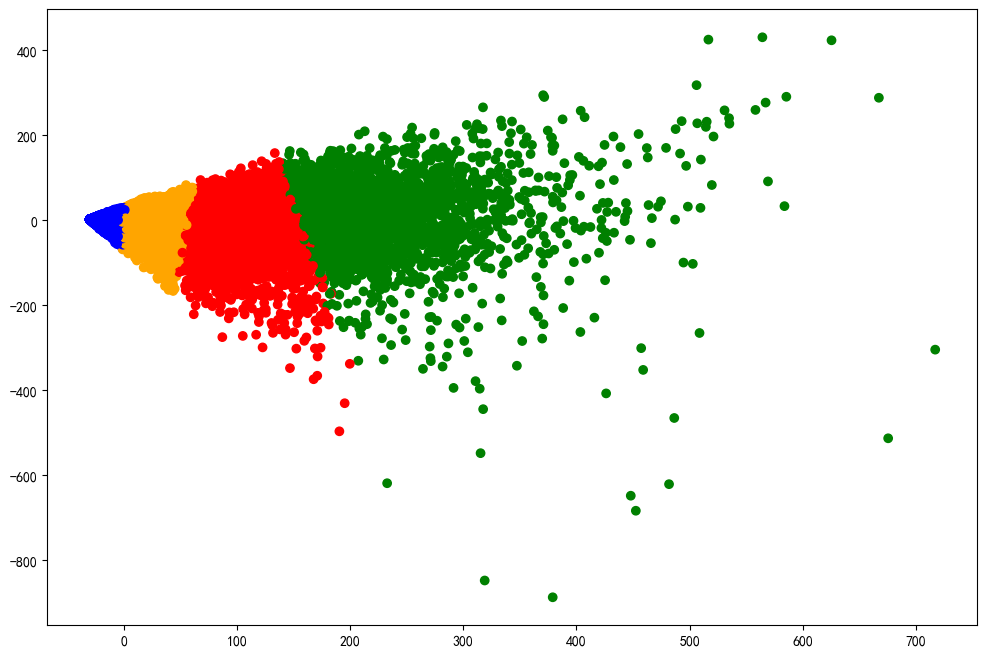

In [32]:
plt.figure(figsize=(12, 8))
plt.scatter(data[:, 0], data[:, 1], color=[
            ['orange', 'blue', 'green', 'red'][_] for _ in predict])
plt.show()

---

In [40]:
# 异常值处理
X = np.random.rand(50, 1)
X[0, 0] = 10
X[1, 0] = 11

In [41]:
# 分位数法：通过计算数据的分位数来识别异常值，通常使用1.5倍的四分位距（IQR）来定义异常值的范围。
# 公式：下界 = Q1 - 1.5 * IQR，上界 = Q3 + 1.5 * IQR，其中Q1和Q3分别是数据的第25和第75百分位数，IQR = Q3 - Q1。

df = pd.DataFrame(X, columns=['value'])
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# df['outlier'] = (df['value'] < lower_bound) | (df['value'] > upper_bound)
df['outerlier'] = df['value'].apply(
    lambda x: x < lower_bound or x > upper_bound)
df.head()

,value,outerlier
0,10.000000,True
1,11.000000,True
2,0.452785,False
3,0.395374,False
4,0.190915,False
